# Objective sweep results

Loads a finished (or in-progress) run of `experiments/run_objective_sweep.py`
(or any `experiments.sweep.run_sweep` call) and inspects it: the headline
sim-vs-bounds table, a plot against a swept axis, and how to drop into one
trial's full detail.

Nothing here re-runs the sweep -- it only reads what is already on disk under
`experiments/results/<run_name>/`. See `experiments/README.md` for what each
column means and for the sweep-side gotchas (pinning `arrival_horizon`,
the window's two edges, DW's LB-only default, etc.).

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from experiments.objective_sweep import load_results, comparison_table
from experiments.core import DEFAULT_OUT_DIR
from visualization.style import new_figure, style_axes, style_legend, palette

## Point this at a run

`RUN_NAME` is the sub-directory name you passed as `run_name` to `run_sweep`
(or the auto-generated `sweep_<timestamp>` if you didn't pass one -- check
`experiments/results/` on disk, or the last line `run_sweep` printed, if
you're not sure).

In [2]:
RUN_NAME = "test"  # <-- edit to the run you want to inspect

run_dir = DEFAULT_OUT_DIR / RUN_NAME
df = load_results(RUN_NAME)
print(f"{len(df)} trial(s) loaded from {run_dir / 'results.csv'}")
df.head()

6 trial(s) loaded from D:\OneDrive - University of Toronto\Uni\Ph.D\Thesis\Chapter 2 - Queueing\Python Codes\experiments\results\test\results.csv


,trial_id,n_piles,n_connectors,n_modules,p_module,queue_capacity,mean_interarrival,max_time,warmup_period,flush_queue_at_warmup,...,dw_mean_sojourn_LB,dw_UB,dw_gap,dw_total_sojourn_UB,dw_mean_sojourn_UB,dw_whole_module_feasible,dw_n_vehicles,dw_n_optimized,dw_K,dw_runtime_s
0,0,1,2,6,25.0,1000,10.0,120,360,False,...,75.759834,NaN,NaN,NaN,NaN,NaN,25,25,60,32.781402
1,1,1,2,6,25.0,1000,12.0,120,360,False,...,59.915692,NaN,NaN,NaN,NaN,NaN,17,17,60,25.214690
2,2,1,2,6,25.0,1000,15.0,120,360,False,...,40.639147,NaN,NaN,NaN,NaN,NaN,13,13,60,20.389396
3,3,1,2,6,25.0,1000,20.0,180,360,False,...,32.759078,NaN,NaN,NaN,NaN,NaN,12,12,90,23.960331
4,4,1,2,6,25.0,1000,30.0,240,360,False,...,29.947341,NaN,NaN,NaN,NaN,NaN,6,6,240,64.800865


## Run metadata

`run_meta.json` records the sweep definition and timing: every `TrialConfig`
that was queued (as a dict, via `to_row()`), which of the three stages
(`sim`/`exact`/`dw`) were switched on, and start/finish/total runtime.

In [3]:
meta = json.loads((run_dir / "run_meta.json").read_text())
print("stages run:", meta["stages"])
print("n_trials:  ", meta["n_trials"])
print("started:   ", meta["started"], " finished:", meta.get("finished", "(in progress)"))
if "total_runtime_s" in meta:
    print(f"total runtime: {meta['total_runtime_s']:.1f} s")

stages run: {'sim': True, 'exact': True, 'dw': True}
n_trials:   6
started:    2026-09-20T22:09:41  finished: 2026-09-21T02:13:31
total runtime: 14628.2 s


## Headline view: sim vs. grid vs. exact vs. DW's lower bound

`comparison_table` pulls out the four sources' mean sojourn for one cohort
(default `"all"`) alongside the knobs that identify each row.

**`group` is the important argument.** Every source now reports two
populations:

* `"arrived"` (the default) -- every vehicle the models were given, with
  unfinished ones censored at the horizon. All four columns cover the same
  set, so this is the one to compare on.
* `"completed"` -- only vehicles that received their full energy. Readable,
  but it conditions on an outcome: it drops precisely the longest sojourns,
  and the simulation and the models drop *different* vehicles.

Comparing a `completed` number against an `arrived` one is what makes a
proven optimum look *worse* than feasible FIFO. The `sim_n`/`grid_n`/
`exact_n` columns are shown so any residual mismatch stays visible.

Remember `sim` is continuous-time and NOT the like-for-like target -- compare
against `grid` (that same schedule replayed on the `delta` slot grid);
`dw_LB` is a certified lower bound and `exact` is the MILP's incumbent, so on
every row you should see `grid >= exact >= dw_LB`.

In [4]:
GROUP = "arrived"   # "arrived" (comparable) | "completed" (finished only)

table = comparison_table(df, cohort="all", group=GROUP)
table

,mean_interarrival,max_time,delta,mip_gap,gap_tolerance,sim,grid,exact,dw_LB,sim_n,grid_n,exact_n,exact_status,dw_status,sim_runtime_s,exact_runtime_s,dw_runtime_s
0,10.0,120,2.0,0.0010,0.000001,81.773347,82.320000,77.680000,75.759834,25.0,25.0,25.0,TIME_LIMIT,CONVERGED,0.034382,3600.867429,32.781402
1,12.0,120,2.0,0.0010,0.000001,67.260050,67.882353,62.823529,59.915692,17.0,17.0,17.0,TIME_LIMIT,CONVERGED,0.070785,3600.415231,25.214690
2,15.0,120,2.0,0.0010,0.000001,47.140645,48.153846,43.384615,40.639147,13.0,13.0,13.0,TIME_LIMIT,CONVERGED,0.061538,3600.197627,20.389396
3,20.0,180,2.0,0.0001,0.000001,36.318412,37.000000,34.666667,32.759078,12.0,12.0,12.0,TIME_LIMIT,CONVERGED,0.027471,1798.661757,23.960331
4,30.0,240,1.0,0.0001,0.000001,32.987891,33.500000,31.166667,29.947341,6.0,6.0,6.0,TIME_LIMIT,CONVERGED,0.023799,1800.276870,64.800865
5,60.0,240,1.0,0.0001,0.000001,23.097426,23.400000,23.200000,22.617576,5.0,5.0,5.0,OPTIMAL,CONVERGED,0.004534,9.881397,44.889738


## All columns

`results.csv` is wide (config knobs + populations + per-source, per-cohort
metrics -- see the README's column-group table). Group by prefix to see
what's available for a given source.

In [5]:
prefixes = ["inst_", "sim_", "grid_", "exact_", "dw_"]
for p in prefixes:
    cols = [c for c in df.columns if c.startswith(p)]
    print(f"{p:8s} ({len(cols)} columns): {cols}")

inst_    (8 columns): ['inst_n_vehicles', 'inst_n_dropped_late_arrivals', 'inst_n_optimized', 'inst_n_boundary_vehicles', 'inst_n_discarded', 'inst_n_measurement', 'inst_n_queued', 'inst_n_boundary']
sim_     (23 columns): ['sim_clock_end', 'sim_runtime_s', 'sim_completed_measurement_n', 'sim_completed_measurement_total_sojourn', 'sim_completed_measurement_mean_sojourn', 'sim_completed_measurement_queued_n', 'sim_completed_measurement_queued_total_sojourn', 'sim_completed_measurement_queued_mean_sojourn', 'sim_completed_all_n', 'sim_completed_all_total_sojourn', 'sim_completed_all_mean_sojourn', 'sim_arrived_measurement_n', 'sim_arrived_measurement_n_censored', 'sim_arrived_measurement_total_sojourn', 'sim_arrived_measurement_mean_sojourn', 'sim_arrived_measurement_queued_n', 'sim_arrived_measurement_queued_n_censored', 'sim_arrived_measurement_queued_total_sojourn', 'sim_arrived_measurement_queued_mean_sojourn', 'sim_arrived_all_n', 'sim_arrived_all_n_censored', 'sim_arrived_all_total

## Plot: mean sojourn vs. a swept knob

Edit `X_AXIS` (the column to put on the x-axis) and `GROUP_BY` (one line per
distinct value, or `None` to disable) to match whatever you actually swept.
Color encodes the source (sim/grid/exact/dw_LB); line style encodes the
`GROUP_BY` value.

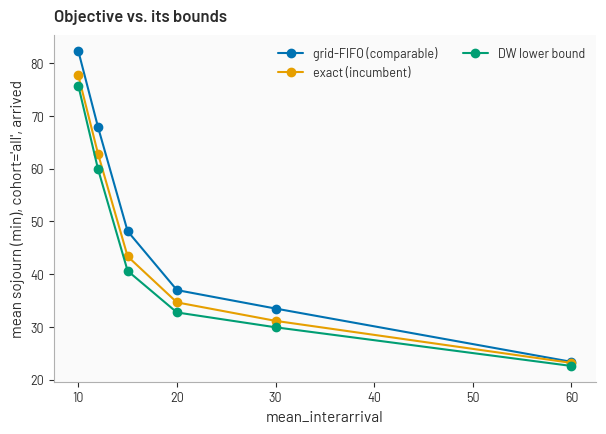

In [6]:
X_AXIS = "mean_interarrival"   # column to put on the x-axis
GROUP_BY = None                # one line per value; set to None to disable
COHORT = "all"                 # "measurement" | "measurement_queued" | "all"
GROUP = "arrived"              # "arrived" (comparable) | "completed"

sources = [
    #(f"sim_{GROUP}_{COHORT}_mean_sojourn", "sim (continuous)"),
    (f"grid_{GROUP}_{COHORT}_mean_sojourn", "grid-FIFO (comparable)"),
    (f"exact_{GROUP}_{COHORT}_mean_sojourn", "exact (incumbent)"),
    ("dw_mean_sojourn_LB", "DW lower bound"),  # DW has no per-cohort LB -- see README
]
sources = [(col, label) for col, label in sources if col in df.columns]
colors = palette(len(sources))
linestyles = ["-", "--", ":", "-."]
groups = sorted(df[GROUP_BY].unique()) if GROUP_BY else [None]

fig, ax = new_figure(figsize=(7, 4.5))
for gi, gval in enumerate(groups):
    sub = df[df[GROUP_BY] == gval].sort_values(X_AXIS) if GROUP_BY else df.sort_values(X_AXIS)
    for (col, label), color in zip(sources, colors):
        line_label = f"{label} ({GROUP_BY}={gval:g})" if GROUP_BY else label
        ax.plot(sub[X_AXIS], sub[col], marker="o", color=color,
                 linestyle=linestyles[gi % len(linestyles)], label=line_label)

ax.set_xlabel(X_AXIS)
ax.set_ylabel(f"mean sojourn (min), cohort='{COHORT}', {GROUP}")
style_axes(ax, title="Objective vs. its bounds")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

,mean_interarrival,max_time,delta,exact_status,dw_status,grid,exact,exact_vs_grid,dw_LB,dw_LB_vs_grid
0,10.0,120,2.0,TIME_LIMIT,CONVERGED,82.32,77.68,4.64,75.76,6.56
1,12.0,120,2.0,TIME_LIMIT,CONVERGED,67.88,62.82,5.06,59.92,7.97
2,15.0,120,2.0,TIME_LIMIT,CONVERGED,48.15,43.38,4.77,40.64,7.51
3,20.0,180,2.0,TIME_LIMIT,CONVERGED,37.00,34.67,2.33,32.76,4.24
4,30.0,240,1.0,TIME_LIMIT,CONVERGED,33.50,31.17,2.33,29.95,3.55
5,60.0,240,1.0,OPTIMAL,CONVERGED,23.40,23.20,0.20,22.62,0.78


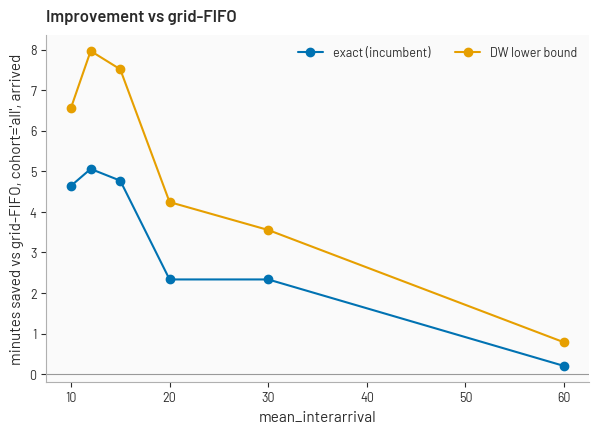

In [7]:
AS_PCT = False  # True: % of grid-FIFO; False: minutes saved (grid - M)

# Improvement vs grid-FIFO (same GROUP / COHORT as the plot cell).
#
# Mean sojourn is minutes per vehicle; lower is better. For a method M
# (exact incumbent, or DW lower bound),
#
#     abs_improvement = grid - M                         # minutes saved
#     pct_improvement = 100 * (grid - M) / grid          # share of grid removed
#
# AS_PCT chooses which of those the table and plot show. Positive means M
# is better than grid-FIFO.
#
# Exact's figure is the improvement of the MILP incumbent (a feasible
# schedule). On a TIME_LIMIT row that understates the true optimum's
# improvement (exact >= z*). DW's figure is the improvement of the
# certified lower bound (dw_LB <= z*), so it is an *upper* bound on how
# much the true optimum can beat grid-FIFO.

grid_col = f"grid_{GROUP}_{COHORT}_mean_sojourn"
exact_col = f"exact_{GROUP}_{COHORT}_mean_sojourn"
dw_col = "dw_mean_sojourn_LB"

id_cols = [c for c in (X_AXIS, "max_time", "delta", "exact_status", "dw_status") if c in df.columns]
imp = df[id_cols].copy()
imp["grid"] = df[grid_col]
if exact_col in df.columns:
    imp["exact"] = df[exact_col]
    abs_exact = imp["grid"] - imp["exact"]
    imp["exact_vs_grid"] = 100.0 * abs_exact / imp["grid"] if AS_PCT else abs_exact
if dw_col in df.columns:
    imp["dw_LB"] = df[dw_col]
    abs_dw = imp["grid"] - imp["dw_LB"]
    imp["dw_LB_vs_grid"] = 100.0 * abs_dw / imp["grid"] if AS_PCT else abs_dw

imp = imp.sort_values(X_AXIS)
display(imp.round(2))

plot_sources = [
    (col, label)
    for col, label in (
        ("exact_vs_grid", "exact (incumbent)"),
        ("dw_LB_vs_grid", "DW lower bound"),
    )
    if col in imp.columns
]
ylabel = (
    f"% improvement vs grid-FIFO, cohort='{COHORT}', {GROUP}"
    if AS_PCT
    else f"minutes saved vs grid-FIFO, cohort='{COHORT}', {GROUP}"
)
colors = palette(len(plot_sources))
fig, ax = new_figure(figsize=(7, 4.5))
for (col, label), color in zip(plot_sources, colors):
    ax.plot(imp[X_AXIS], imp[col], marker="o", color=color, label=label)
ax.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax.set_xlabel(X_AXIS)
ax.set_ylabel(ylabel)
style_axes(ax, title="Improvement vs grid-FIFO")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

## How much of each row is censored?

The censored share is what decides whether a row is trustworthy. A row where
half the vehicles never finished is dominated by the censoring convention,
not by scheduling quality -- that is the regime where the `completed` and
`arrived` groups disagree most, and where a short `max_time` shows up.

`exact_n_completed_at_horizon` counts vehicles that finished *exactly* at the
horizon edge (`D_j == K` yet fully charged). A nonzero count means the
horizon is binding on the optimum, and is also why completion is tested by
energy rather than by departure slot.

In [8]:
COHORT = "all"
cens = pd.DataFrame({
    "arrived_n": df[f"exact_arrived_{COHORT}_n"],
    "completed_n": df[f"exact_completed_{COHORT}_n"],
    "censored_n": df[f"exact_arrived_{COHORT}_n_censored"],
})
cens["censored_share"] = cens["censored_n"] / cens["arrived_n"]
for col in ("exact_n_completed_at_horizon", "exact_n_at_horizon"):
    if col in df.columns:
        cens[col.replace("exact_", "")] = df[col]
cens.round(3)

,arrived_n,completed_n,censored_n,censored_share,n_completed_at_horizon,n_at_horizon
0,25.0,8.0,17.0,0.680,0,17
1,17.0,8.0,9.0,0.529,0,9
2,13.0,7.0,6.0,0.462,0,6
3,12.0,8.0,4.0,0.333,0,4
4,6.0,5.0,1.0,0.167,0,1
5,5.0,4.0,1.0,0.200,0,1


## One trial's full detail

`results.csv` is the flattened view; `trials/trial_NNN.json` keeps the same
trial nested (and is where you'd look for anything `flatten_trial` didn't
pull into a column). That file also stores `arrivals`: the EV specs the DES
was fed, which is enough to rebuild the episode (`replay_episode` in the
next section). It does **not** store the env object, and it does **not**
include the per-vehicle schedule table (`ConnectorLaneSolution.per_vehicle` /
`DWSolution.per_vehicle`) -- only the aggregate/by-cohort figures
`run_exact`/`run_dw` returned.

In [9]:
TRIAL_ID = 0  # <-- edit to inspect a different row

trial = json.loads((run_dir / "trials" / f"trial_{TRIAL_ID:03d}.json").read_text())
print("config:", {k: v for k, v in trial["config"].items() if k in
      ("mean_interarrival", "max_time", "delta", "mip_gap", "gap_tolerance",
       "gap_tolerance_target_min", "boundary_mode", "objective_cohorts")})
print()
print("counts:  ", trial["counts"])
print("instance:", trial["instance"])
print()
print("exact:", trial["exact"])
print()
print("dw:   ", trial["dw"])

config: {'mean_interarrival': 10.0, 'max_time': 120, 'delta': 2.0, 'boundary_mode': 'optimize', 'objective_cohorts': 'boundary+measurement+queued', 'mip_gap': 0.001, 'gap_tolerance': 1e-06, 'gap_tolerance_target_min': 1}

counts:   {'n_arrived_post_warmup': 11, 'n_queued_at_warmup_end': 12, 'n_in_service_at_warmup_end': 2, 'n_arrived_total': 41, 'n_finished_total': 22, 'n_dropped_total': 0, 'n_flushed_at_warmup': 0, 'sim_clock_end': 480.0, 'sim_runtime_s': 0.03438159998040646}
instance: {'n_vehicles': 25, 'n_dropped_late_arrivals': 0, 'late_arrival_ids': [], 'n_optimized': 25, 'n_boundary_vehicles': 2, 'n_discarded': 0, 'cohort_sizes': {'measurement': 11, 'queued': 12, 'boundary': 2}}

exact: {'status': 'TIME_LIMIT', 'objective': 1261.0, 'best_bound': 886.7772382275241, 'mip_gap_achieved': 0.2967666627854686, 'total_sojourn': 1942.0, 'mean_sojourn': 77.68, 'n_vehicles': 25, 'n_optimized': 25, 'K': 60, 'gurobi_runtime_s': 3600.073000192642, 'build_runtime_s': 0.791023200028576, 'solve_r

## Rebuild each trial and print utilization

`trials/trial_NNN.json` stores the arrival specs, not the env. This cell
rebuilds every trial (FIFO, proportional power -- the same rollout the sweep
ran) and prints connector utilization.

* `rho_sim` -- fraction of connector-time that was occupied.
* `rho_theory` -- `lambda_eff / (c * mu)`, with `lambda_eff = n_finished / T`
  and `mu = 1 / E[service]`.
* **full** is the whole clock, warm-up included. **measured** is
  `[warmup_period, T]`, the window the sojourn columns use.

A trial written before arrivals were saved is skipped. Re-run
`experiments.run_objective_sweep` to record them.

In [10]:
from experiments.objective_sweep import episode_utilization, replay_episode

rows = []
for trial_id in range(len(df)):
    path = run_dir / "trials" / f"trial_{trial_id:03d}.json"
    trial = json.loads(path.read_text())
    arrivals = trial.get("arrivals") or []
    cfg = trial["config"]
    tag = cfg.get("label") or ""
    if not arrivals:
        print(
            f"trial {trial_id} {tag}: no arrivals saved "
            "(re-run the sweep to record them)"
        )
        continue

    env = replay_episode(cfg, arrivals)
    full = episode_utilization(env, post_warmup=False)
    measured = episode_utilization(env, post_warmup=True)
    print(
        f"trial {trial_id} {tag}  interarrival={cfg['mean_interarrival']:g}  "
        f"full  rho_sim={full['rho_sim']:.3f}  rho_theory={full['rho_theory']:.3f}  "
        f"measured  rho_sim={measured['rho_sim']:.3f}  "
        f"rho_theory={measured['rho_theory']:.3f}"
    )
    rows.append(
        {
            "trial_id": trial_id,
            "label": tag,
            "mean_interarrival": cfg["mean_interarrival"],
            "max_time": cfg["max_time"],
            "rho_sim_full": full["rho_sim"],
            "rho_theory_full": full["rho_theory"],
            "rho_sim_measured": measured["rho_sim"],
            "rho_theory_measured": measured["rho_theory"],
            "n_finished_measured": measured["n_finished"],
        }
    )

pd.DataFrame(rows).round(3) if rows else print("nothing to replay")

trial 0 6veh: no arrivals saved (re-run the sweep to record them)
trial 1 5veh: no arrivals saved (re-run the sweep to record them)
trial 2 4veh: no arrivals saved (re-run the sweep to record them)
trial 3 3veh: no arrivals saved (re-run the sweep to record them)
trial 4 2veh: no arrivals saved (re-run the sweep to record them)
trial 5 1veh: no arrivals saved (re-run the sweep to record them)
nothing to replay


## Notes / gotchas (see `experiments/README.md` for the full version)

- **`sim` is not the target.** The offline models can only depart on `delta`
  slot boundaries; compare against `grid`, not `sim`.
- **DW has no per-cohort lower bound.** `dw_mean_sojourn_LB` certifies
  whichever `objective_cohorts` that trial was solved over as a whole -- it
  is not a separate bound for `measurement` vs. `all`. If you need a bound
  for one cohort specifically, that cohort must be `objective_cohorts` for
  its own trial.
- **Watch the `n` columns** (`sim_{cohort}_n`, `grid_{cohort}_n`,
  `exact_{cohort}_n`, `dw_n_optimized`) when comparing `sim`/`grid` against
  `exact`/`dw`: the simulation only counts vehicles that *finished* inside
  the run, the offline models count every vehicle they were given. Different
  `n` means different populations -- the mean-sojourn gap is not
  apples-to-apples until `max_time` is long enough that these line up.
- **A sweep over `max_time` (or `warmup_period`) needs `arrival_horizon`
  pinned**, or each value silently redraws the whole EV population instead
  of just changing the window length -- see the README section "Sweeping
  `max_time`: pin the arrival draw".